In [1]:
import py4DSTEM
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from colorsys import hsv_to_rgb
import numpy as np
import matplotlib.pyplot as plt
import string

C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH

# Load Data

In [2]:
# Columns represent Qx, Qy, I, Rx, Ry, Qr, Qphi
#PeaksArray = np.load('PeaksArray.npy')
PeaksArray = np.load('PeaksArray_SmallRange.npy')
Qx = PeaksArray[:, 0]
Qy = PeaksArray[:, 1]
Rx = PeaksArray[:, 3]
Ry = PeaksArray[:, 4]

In [3]:
# Set same text size
plt.rcParams.update({'font.size': 14})

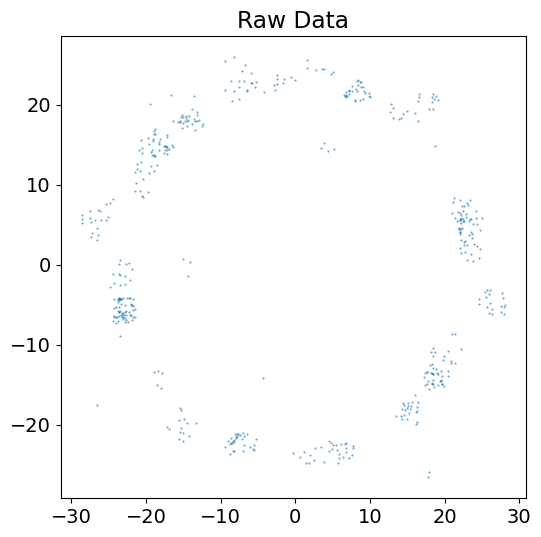

In [4]:
# Plot the data
plt.figure(figsize=[6,6])
plt.title('Raw Data')
plt.scatter(Qx, Qy, s=0.25, alpha=0.7)
plt.show()

# KMeans clustering


Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.


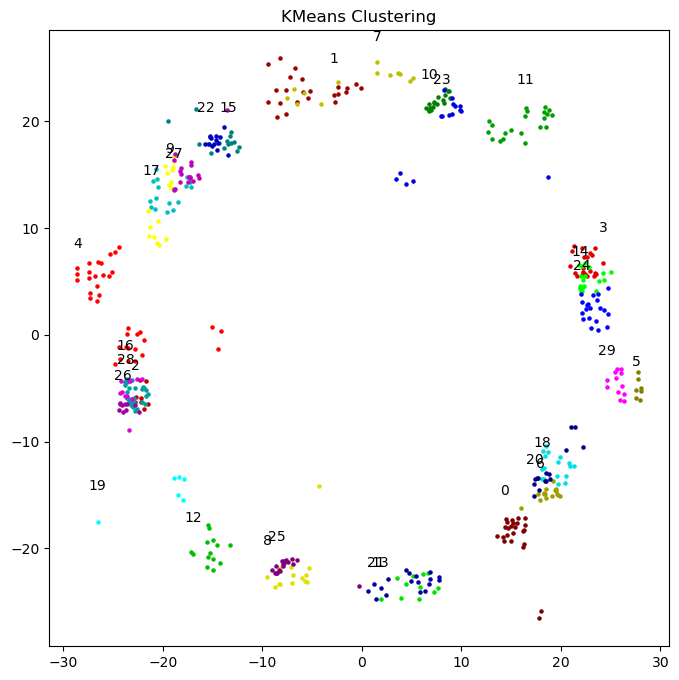

In [7]:
# KMeans Clustering 

# Colours
colours = []
r = 30
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 
     
# Apply KMeans
k = KMeans(n_clusters=r).fit(PeaksArray[:,[0,1,3,4]]*np.array([1, 1, 2, 2]))

# Plot
plt.figure(figsize=[8, 8])
plt.title('KMeans Clustering')

for i in range(r):
    Cluster = PeaksArray[np.where(k.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 1], color=colours[i], label = i, s=5, alpha=1)
         
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 1]+3, 
            int(i),
            horizontalalignment='center'
        )

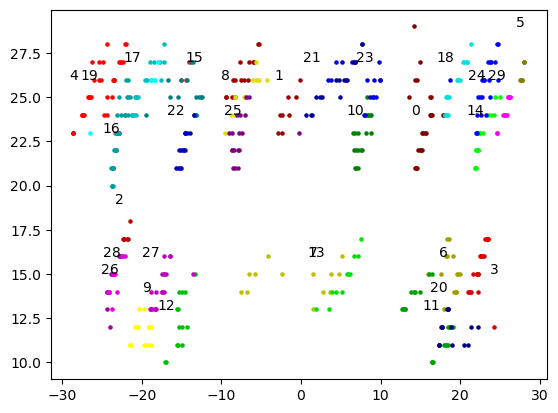

In [8]:
for i in range(r):
    Cluster = PeaksArray[np.where(k.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 3], color=colours[i], label = i, s=5, alpha=1)
         
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 3]+3, 
            int(i),
            horizontalalignment='center'
        )

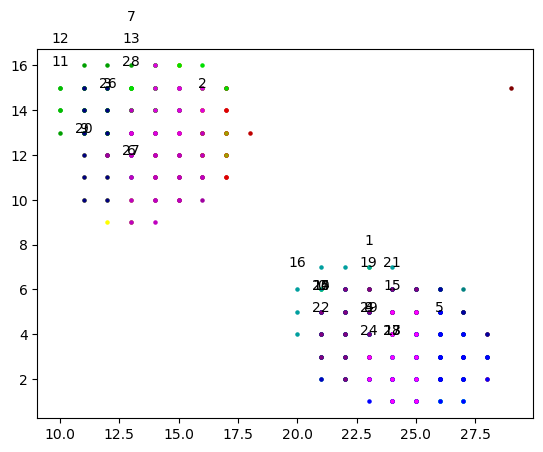

In [9]:
for i in range(r):
    Cluster = PeaksArray[np.where(k.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 3], Cluster[:, 4], color=colours[i], label = i, s=5, alpha=1)
         
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 3], 
            Cluster[n, 4]+3, 
            int(i),
            horizontalalignment='center'
        )

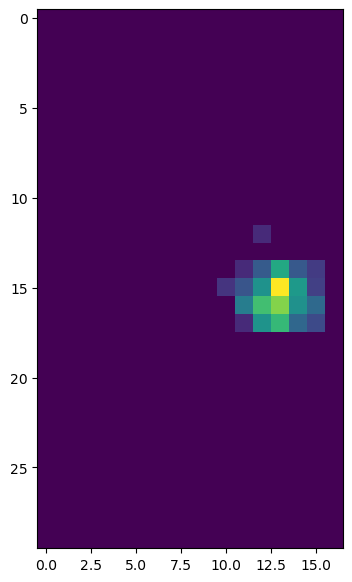

In [10]:
# Virtual Image
label = 3
# Select a specific cluster points
Cluster = PeaksArray[np.where(k.labels_ == label)]

Rxc = Cluster[:, 3]
Ryc = Cluster[:, 4]

# Finding max dimensions of Rx, Ry
Rxmax, Rymax = Rx.max().astype('int')+1, Ry.max().astype('int')+1

# Create image 
image = np.zeros(shape=(Rxmax,Rymax))
image[Rxc.astype('int'), Ryc.astype('int')] = Cluster[:,2]

# Plot
plt.figure(figsize=[7,7])
plt.imshow(image)
plt.show()

In [11]:
len(PeaksArray[np.where(k.labels_ == 17)])

17

In [12]:
PeaksArray[np.where(k.labels_ == 17)]

array([[-21.19735908,  11.9304624 ,  36.27071546,  24.        ,
          1.        ,  24.32414366,  60.62798236],
       [-21.25278859,  12.54211072,  66.46276745,  24.        ,
          2.        ,  24.67763287,  59.45346523],
       [-20.9702334 ,  14.37248548,  65.80043898,  24.        ,
          3.        ,  25.42280527,  55.57421332],
       [-20.67996768,  15.52555293,  32.37042682,  24.        ,
          4.        ,  25.85930891,  53.10249122],
       [-20.80234874,  11.75608386,  93.5425201 ,  25.        ,
          1.        ,  23.89441819,  60.52779634],
       [-20.68760712,  12.78423947, 187.68706227,  25.        ,
          2.        ,  24.31900218,  58.28534115],
       [-20.50329012,  13.88842491, 194.20996313,  25.        ,
          3.        ,  24.76435446,  55.88725227],
       [-20.55312727,  14.62227554,  66.26960375,  25.        ,
          4.        ,  25.22383759,  54.57050792],
       [-19.63094724,  11.48831806,  94.54876221,  26.        ,
          1.    

In [13]:
PeaksArray[np.where(k.labels_ == 17)][2]

array([-20.9702334 ,  14.37248548,  65.80043898,  24.        ,
         3.        ,  25.42280527,  55.57421332])

In [14]:
# Cluster 0
Cluster0 = PeaksArray[np.where(k.labels_ == 17)][0]

Rx = Cluster0[3]
Ry = Cluster0[4]

Rxmax, Rymax = Rx.max().astype('int')+1, Ry.max().astype('int')+1

image0 = np.zeros(shape=(Rxmax,Rymax))
image0[Cluster0[3].astype('int'), Cluster0[4].astype('int')] = Cluster0[2]

# Cluster 1
Cluster1 = PeaksArray[np.where(k.labels_ == 17)][1]

Rx = Cluster1[3]
Ry = Cluster1[4]

Rxmax, Rymax = Rx.max().astype('int')+1, Ry.max().astype('int')+1

image1 = np.zeros(shape=(Rxmax,Rymax))
image1[Cluster1[3].astype('int'), Cluster1[4].astype('int')] = Cluster1[2]


# Cluster 2
Cluster2 = PeaksArray[np.where(k.labels_ == 17)][2]

Rx = Cluster2[3]
Ry = Cluster2[4]

Rxmax, Rymax = Rx.max().astype('int')+1, Ry.max().astype('int')+1

image2 = np.zeros(shape=(Rxmax,Rymax))
image2[Cluster2[3].astype('int'), Cluster2[4].astype('int')] = Cluster2[2]

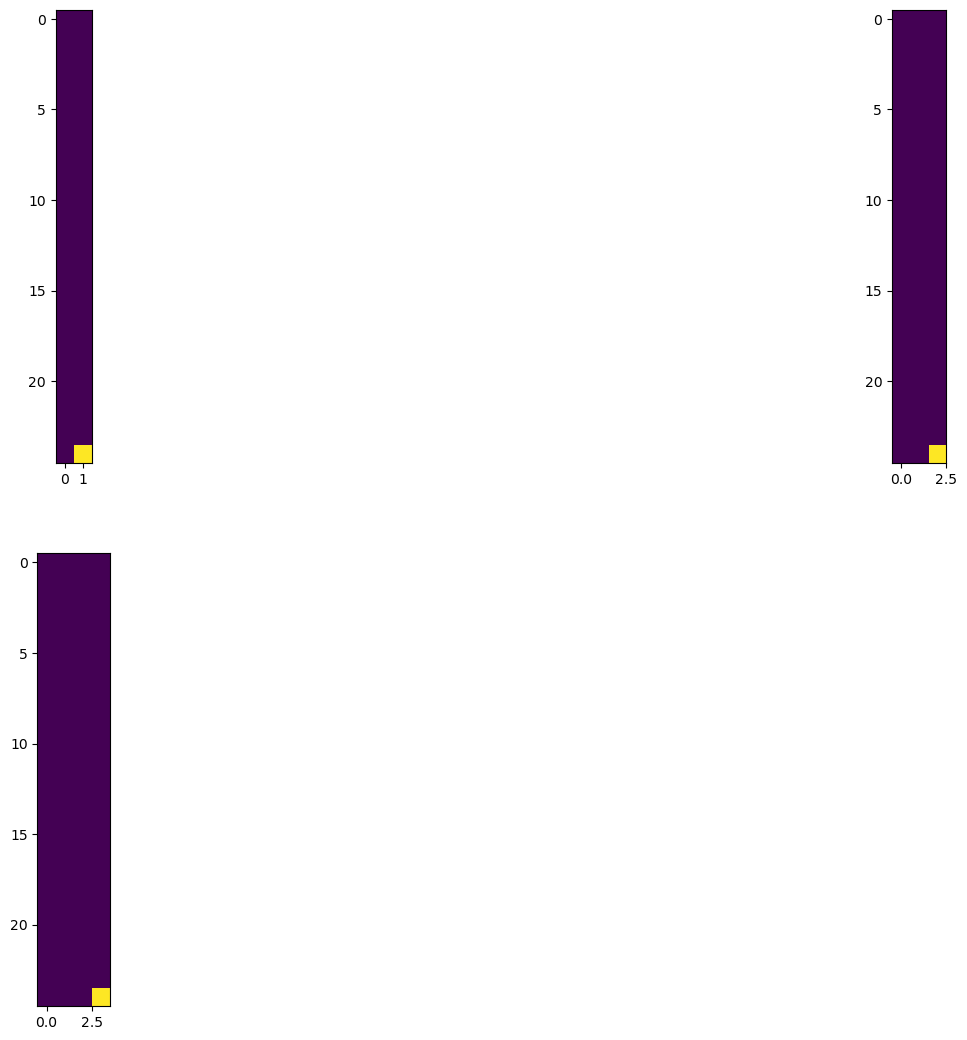

In [15]:
# Plot
plt.figure(figsize=[20, 20])

plt.subplot(3,2,1)
plt.imshow(image0)

plt.subplot(3,2,2)
plt.imshow(image1)

plt.subplot(3,2,3)
plt.imshow(image2)

In [16]:
def KMeansVirtualImage(r, Data, ClusterIndex, Rx_col, Ry_col):
    '''
    Function for plotting the image of a clustered pixel in the real space from reciprocal space.
    Cluster types extract the label from the specified clustering algorithm.

    Data types
    ----------
    ClusterType: String (if db = DBSCAN, then enter db, if k = KMEANS, then k etc.)
    ClusterIndex: Int (select the cluster number)
    Data: numpy array
    Rx_col: Int (corresponds to the column in the dataset)
    Ry_col: Int 

    Returns
    ----------
    matplotlib figure
    '''

    # Colours
    colours = []
    d = 5
    for n in range(r):
        # integers
        h, v = int(n/d), n%d 
        # normalisation
        H = h/(r/d)
        V = (4+v)/8
        S = 1
        c = hsv_to_rgb(H,S,V)
        colours += [c] 
     
    # Apply KMeans
    k = KMeans(n_clusters=r).fit(Data)
     
    # Plot
    plt.figure(figsize=[8,8])
    plt.title('KMeans Clustering')
    for i in range(r):
        Cluster = Data[np.where(k.labels_ == i)]

    # Select a specific cluster points
    Cluster = Data[np.where(k.labels_ == ClusterIndex)]

    Rx = Cluster[:, Rx_col]
    Ry = Cluster[:, Ry_col]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = Rx.max().astype('int')+1, Ry.max().astype('int')+1

    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Cluster[:, Rx_col].astype('int'), Cluster[:, Ry_col].astype('int')] = Cluster[:,2]

    # Plot
    plt.figure(figsize=[7,7])
    plt.imshow(image)
    plt.show()

# Raw Code

# DBSCAN

## Level 1 clustering

In [5]:
# DBScan Parameters
s = 0.4 
eps = 2
db = DBSCAN(eps=eps, min_samples=4).fit(PeaksArray[:,[0,1,3,4]]*np.array([1, 1, s, s])) 

In [6]:
# Colour Scheme
colours = []
r = db.labels_.max()+1
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

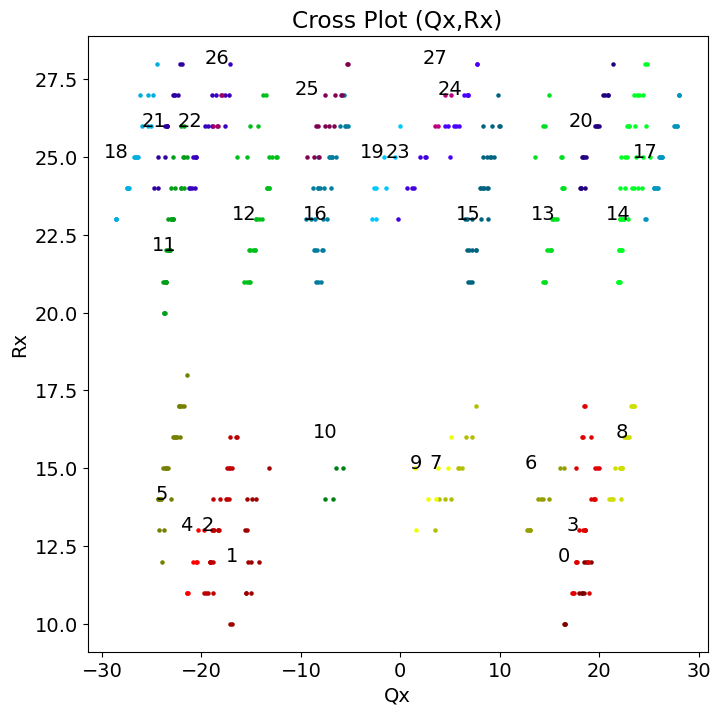

In [7]:
# Cross Plot (Qx,Rx)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qx,Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 3], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 3]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qx')
plt.ylabel('Rx')
plt.show()

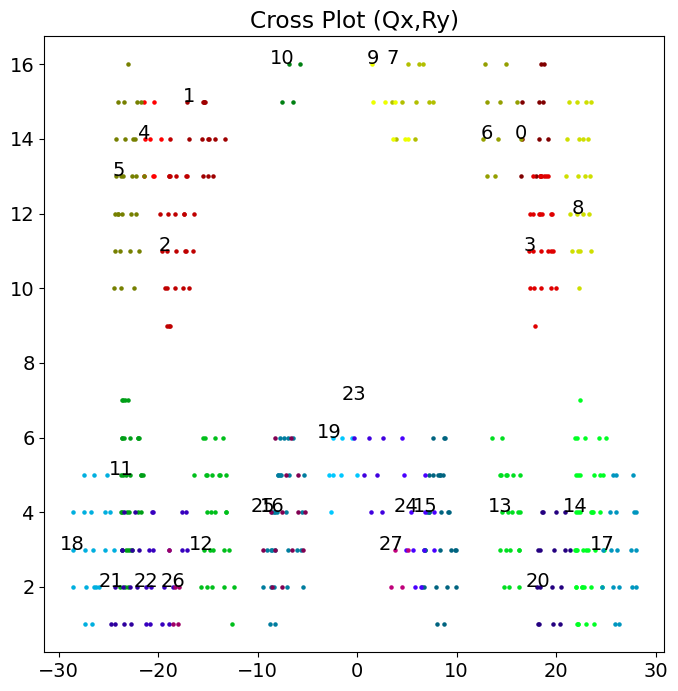

In [8]:
# Cross Plot (Qx,Ry)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qx,Ry)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 4], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 4]+1, 
            int(i),
            horizontalalignment='center'
        )

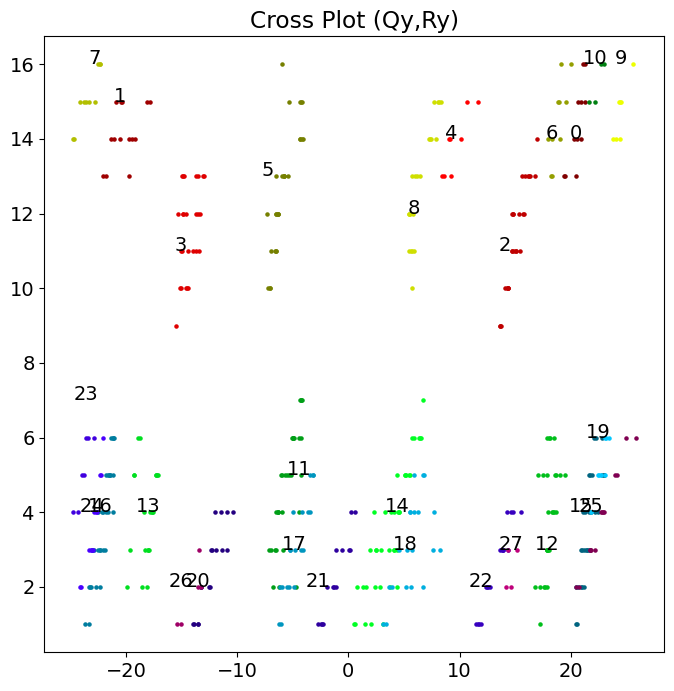

In [9]:
# Cross Plot (Qy,Ry)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qy,Ry)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 4], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 4]+1, 
            int(i),
            horizontalalignment='center'
        )

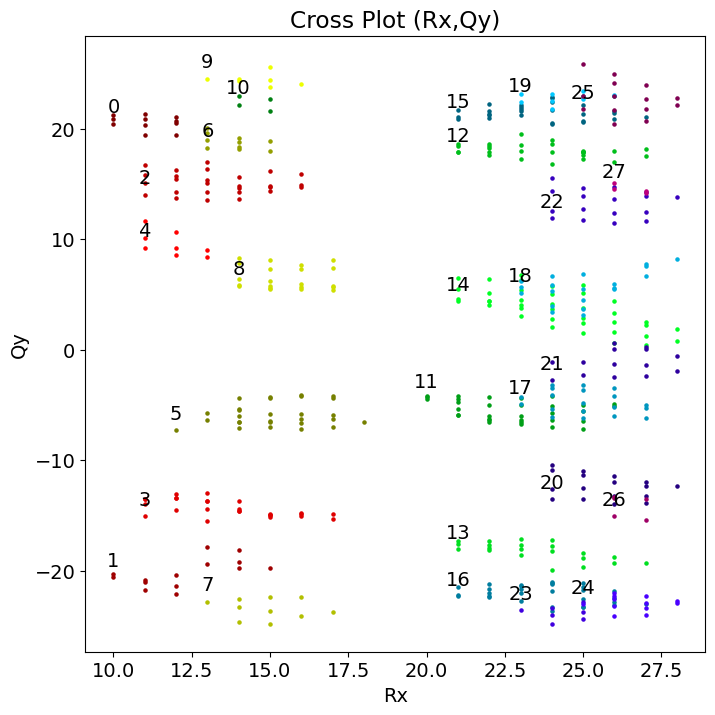

In [10]:
# Cross Plot (Rx,Qy)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Rx,Qy)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 3], Cluster[:, 1], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 3], 
            Cluster[n, 1]+1, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Rx')
plt.ylabel('Qy')
plt.show()

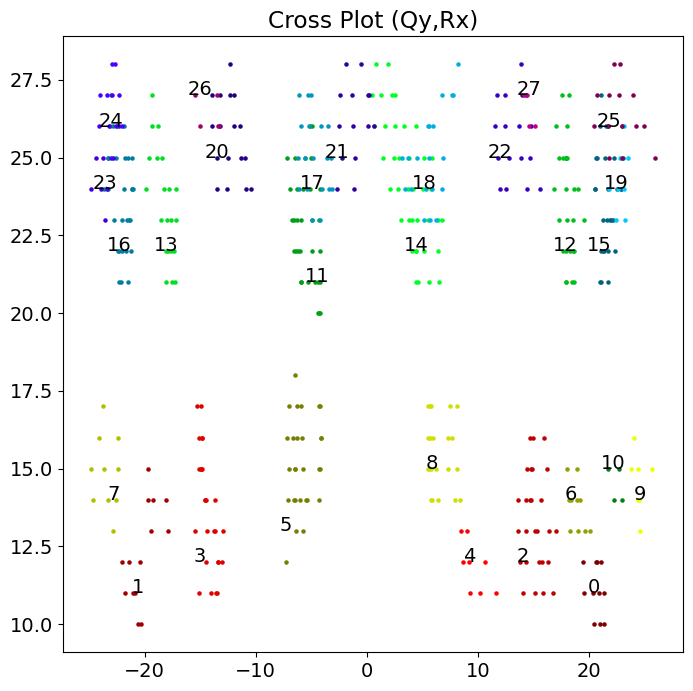

In [11]:
# Cross Plot (Qy,Rx)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qy,Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 3], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 3]+1, 
            int(i),
            horizontalalignment='center'
        )

Text(0, 0.5, 'Qy')

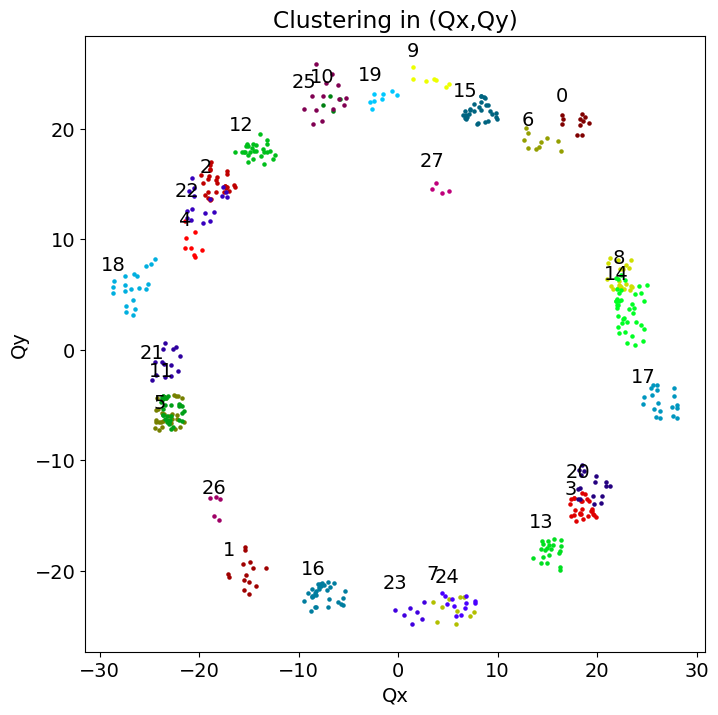

In [12]:
# Apply DBScan
plt.figure(figsize=[8,8])
plt.title('Clustering in (Qx,Qy)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 1], color = colours[i], label = i, s=5, alpha=1)  
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 1]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qx')
plt.ylabel('Qy')
#plt.savefig('DBSCAN_SmallRange')

In [13]:
def VirtualImage(Data, Label, Index):
    Cluster = Data[np.where(Label == Index)]

    Rxc = Cluster[:, 3]
    Ryc = Cluster[:, 4]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = Rx.max().astype('int')+1, Ry.max().astype('int')+1
    
    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,1]

    # Plot
    plt.figure(figsize=[7,7])
    plt.title('Virtual Image for Cluster 10')
    plt.xlabel('Ry')
    plt.ylabel('Rx')
    plt.imshow(image)
    plt.show()

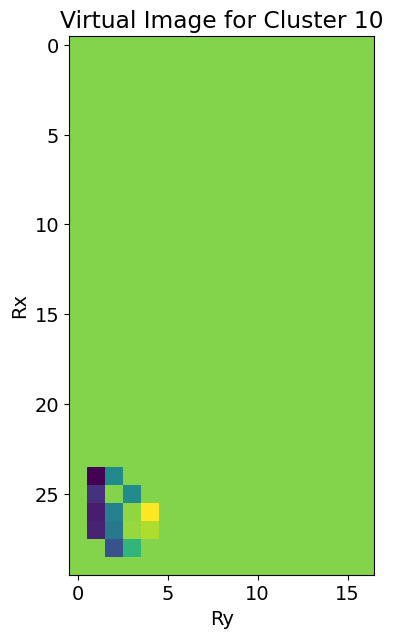

In [14]:
VirtualImage(PeaksArray, db.labels_, 21)

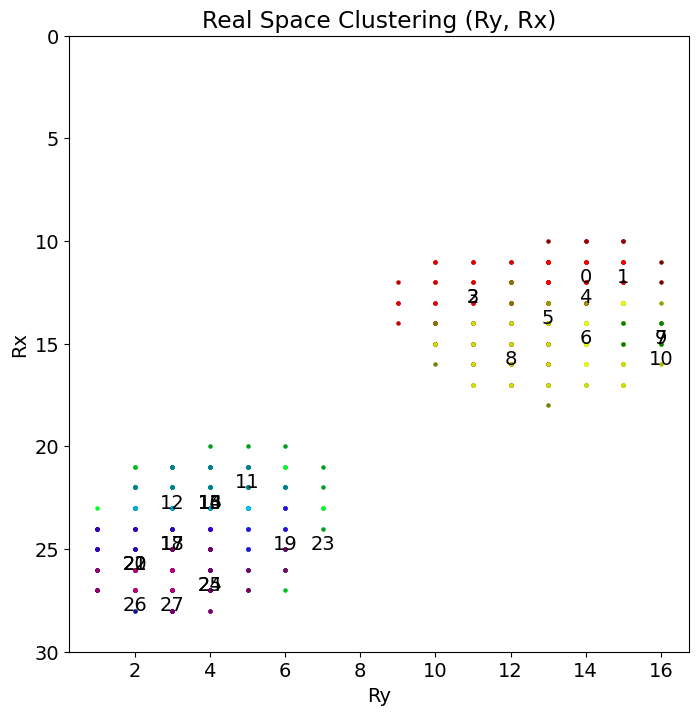

In [15]:
# Real space
plt.figure(figsize=[8,8])
plt.title('Real Space Clustering (Ry, Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 4], Cluster[:, 3], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],1000): # number of iterations 
        plt.text(
            Cluster[n, 4]+1, 
            Cluster[n, 3]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Ry')
plt.ylabel('Rx')
plt.ylim(30,0)
plt.show()

In [16]:
def VirtualImage(Data, Label, Index):
    Cluster = Data[np.where(Label == Index)]

    Rxc = Cluster[:, 3]
    Ryc = Cluster[:, 4]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = Rx.max().astype('int')+1, Ry.max().astype('int')+1
    
    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,1]

    # Plot
    plt.figure(figsize=[7,7])
    plt.title('Virtual Image for Cluster 10')
    plt.xlabel('Ry')
    plt.ylabel('Rx')
    plt.imshow(image)
    plt.show()

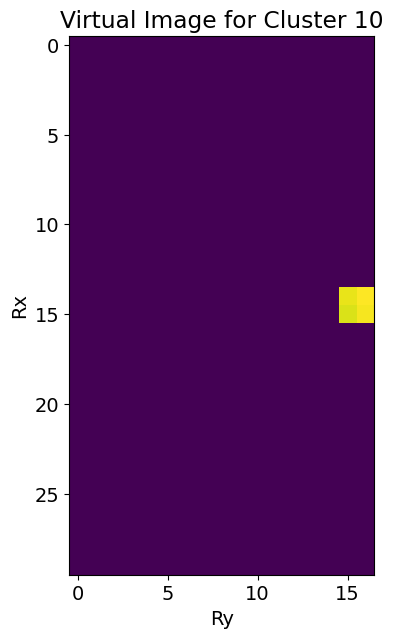

In [17]:
#plt.title('Virtual Image for Cluster 19')
VirtualImage(PeaksArray, db.labels_, 10)

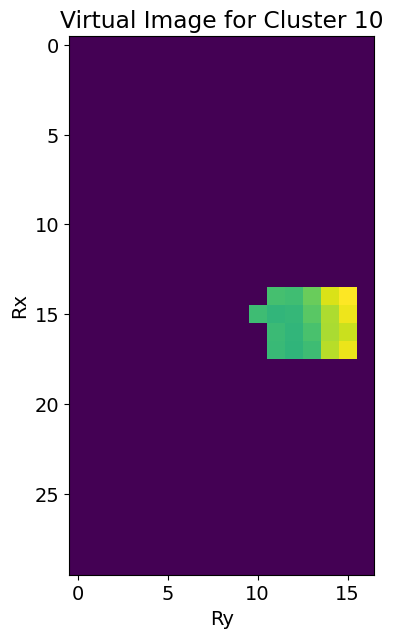

In [18]:
VirtualImage(PeaksArray, db.labels_, 8)

## Centre of Mass

In [19]:
# find COM for each cluster
# could compare to center_of_mass equation from scipy
def COM_X(m,x):
    m = np.array(m)
    x = np.array(x)
    return (np.sum(m * x)) / np.sum(m)

def COM_Y(m,y):
    m = np.array(m)
    y = np.array(y)
    return (np.sum(m * y)) / np.sum(m)

def Cluster_COM(Data, Range, Weight = True):
    COM_Weighted = []
    COM = []

    # loop over all clusters
    for p in Range: # loop over the number of clusters
        Cluster = Data[np.where(db.labels_ == p)]

        if Weight == True:
            # COM weighting
            COM_Weighted.append((
                COM_X(Cluster[:,2], Cluster[:,3]),
                COM_Y(Cluster[:,2], Cluster[:,4])
            ))

        if Weight == False:
            #COM no weighting
            COM.append((
                COM_X(1, Cluster[:,3]),
                COM_Y(1, Cluster[:,4])
            ))
            
    return COM_Weighted, COM

# could clean up function by add where statement so if weighting, if not do without weighting

In [20]:
# find COM for each cluster
# could compare to center_of_mass equation from scipy
def COM_X(m,x):
    m = np.array(m)
    x = np.array(x)
    return (np.sum(m * x)) / np.sum(m)

def COM_Y(m,y):
    m = np.array(m)
    y = np.array(y)
    return (np.sum(m * y)) / np.sum(m)

def Cluster_COM(Data, Range, Weight=True):
    COM_Values = []

    # loop over all clusters
    for p in Range: # loop over the number of clusters
        Cluster = Data[np.where(db.labels_ == p)]

        if Weight:
            # COM weighting
            COM_Values.append((
                COM_X(Cluster[:,2], Cluster[:,3]),
                COM_Y(Cluster[:,2], Cluster[:,4])
            ))

        else:
            #COM no weighting
            COM_Values.append((
                COM_X(1, Cluster[:,3]),
                COM_Y(1, Cluster[:,4])
            ))
            
    return COM_Values

In [21]:
Data = PeaksArray
Range = np.arange(0, max(db.labels_)+1,1)

In [22]:
COM_Values = Cluster_COM(Data, Range, Weight = True)

In [23]:
COM_Values = np.array(COM_Values)

## Level 2 Clustering (Clustering on COM)

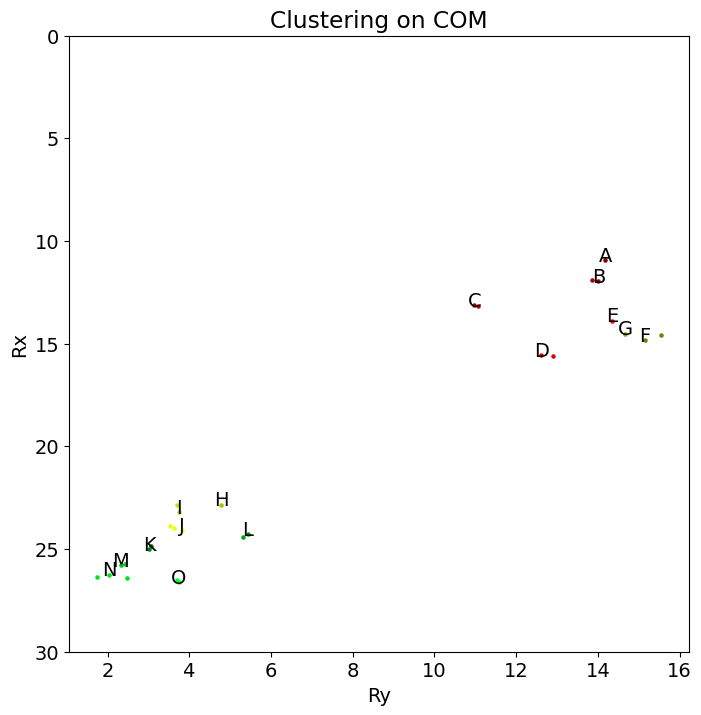

In [90]:
# Second level clustering on COM
db2 = DBSCAN(eps=0.5, min_samples=1).fit(COM_Values)

# Plot
plt.figure(figsize=[8,8])
plt.title('Clustering on COM')

Text = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

for i in range(r):   
    Cluster = COM_Values[np.where(db2.labels_ == i)]
    scatter = plt.scatter(Cluster[:,1], Cluster[:,0], color = colours[i], label = i, s=5, alpha=1)

    for n in range(0,Cluster.shape[0],1000): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 0]+.05, 
            str(Text[i]),
            horizontalalignment='center'
        )
plt.ylim(30,0)
plt.xlabel('Ry')
plt.ylabel('Rx')
plt.show()

In [82]:
#print(Cluster)

In [94]:
def VirtualImage(Data, Label, Index):
    Cluster = Data[np.where(Label == Index)]

    Rxc = Cluster[:, 0]
    Ryc = Cluster[:, 1]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = Rx.max().astype('int')+1, Ry.max().astype('int')+1
    
    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,1]

    # Plot
    plt.figure(figsize=[7,7])
    plt.title('Virtual Image for Cluster H')
    plt.xlabel('Ry')
    plt.ylabel('Rx')
    plt.imshow(image)
    plt.show()

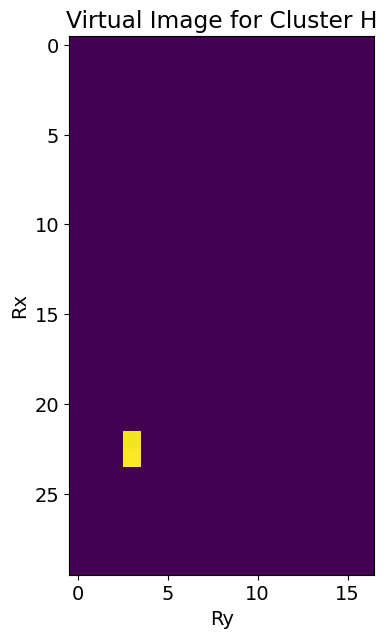

In [95]:
VirtualImage(COM_Values, db2.labels_, 8)

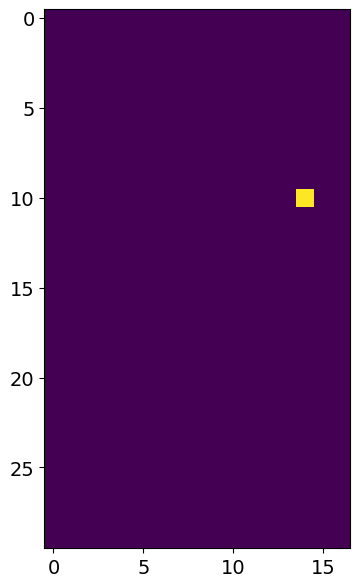

In [86]:
VirtualImage(COM_Values, db2.labels_, 0)

In [42]:
L2numlabs = np.unique(db2.labels_)

In [26]:
L2letterlabs = string.ascii_uppercase[:L2numlabs.shape[0]]

In [27]:
dict(list(zip(L2letterlabs,L2numlabs)))

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'N': 13,
 'O': 14}

In [28]:
#dict(list(zip(L2letterlabs,L2numlabs))) # make sure to use this

In [29]:
# next create some virtual or diffraction patterns, for example compare A and C clusters
# plot in Q space or R space or compare both using the intensity
# if one varies in size like A small or C large then could mean same crystal both different size due to their space
# other results would indicate different crystals
# use like - or x for plotting to ease visualisation

In [30]:
Cluster = COM_Values[np.where(db2.labels_ == 0)]
print(Cluster)

[[10.9219593  14.17869294]]


In [31]:
Data[np.where(db.labels_ == 0)]

array([[ 16.43601456,  20.45388999,  35.35892919,  10.        ,
         13.        ,  26.23936338, -38.78411383],
       [ 16.55223396,  20.93720501, 147.81662886,  10.        ,
         14.        ,  26.68975464, -38.32868345],
       [ 16.51736303,  21.28924298,  51.79214404,  10.        ,
         15.        ,  26.94541052, -37.80627277],
       [ 17.93881843,  19.48176765, 124.05827667,  11.        ,
         13.        ,  26.48283364, -42.63888172],
       [ 18.27212501,  20.32465009, 207.97201738,  11.        ,
         14.        ,  27.33060471, -41.9559541 ],
       [ 18.28599229,  20.89315707, 107.48560425,  11.        ,
         15.        ,  27.76511347, -41.19288242],
       [ 18.44544882,  21.30991597,  48.83604789,  11.        ,
         16.        ,  28.18416401, -40.87882678],
       [ 18.48414806,  19.43824055,  34.40582532,  12.        ,
         13.        ,  26.82366354, -43.55879481],
       [ 19.15345342,  20.56834894,  59.62549441,  12.        ,
         14.    

In [37]:
VirtualImage(COM_Values, db2.labels_, 3)

IndexError: index 3 is out of bounds for axis 1 with size 2

In [38]:
VirtualImage(COM_Values, db2.labels_, 10)

IndexError: index 3 is out of bounds for axis 1 with size 2

## Level 1 and 2 cluster

In [129]:
Level1_COM = COM_Values
print(np.array(Level1_COM[0]))
print(np.array(Level1_COM[0:1]))

# write a loop with np.where, loop over each lvl1 index and match with lvl2 COM ?

[10.9219593  14.17869294]
[[10.9219593  14.17869294]]


In [125]:
A = COM_Values[np.where(db2.labels_ == 0)]
print(np.array(A))

[[10.9219593  14.17869294]]


In [126]:
B = COM_Values[np.where(db2.labels_ == 1)]
print(B)

[[11.96401202 14.00912241]
 [11.89992438 13.85829828]]


In [127]:
#print(np.arange(0, len(Level1_COM)+1, 1))

In [130]:
if np.array(Level1_COM[0:1]) == A:
    print(True)
    

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [113]:
for i in np.arange(0, len(Level1_COM)+1, 1):
    A = []
    if Level1_COM[i] == COM_Values[np.where(db2.labels_ == 0)]:
        A.append(Level1_COM[i])
    

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## Centroids

In [91]:
#print(Cluster['A'])
ClusterA = COM_Values[np.where(db2.labels_ == 0)]

notes:
find centre of mass of clusters 
run through each cluster
could cluster the centre of mass numbers
this tells you similarities of diffraction / crystal etc. 

apply weighting using intensities - could plot in different spaces Q or R or look at the cross sections between them to investigate spatial differences

can also go through each cluster virtual image and see if it aligns with the original cut_data

read through the paper which identities different crystals in the particle

preference to dbscan according to supervisor

plot virtual images of individual clusters and bring back together
